## Uso en el TFB

El Notebook 10 usa estas capas para obtener indicadores territoriales de infraestructura eléctrica, entre ellos:

- longitud de líneas y cables eléctricos;
- longitud de líneas de alta tensión de 110 kV o más;
- número de subestaciones;
- densidades territoriales de líneas y subestaciones.

En el IIT-CPD final, la dimensión de Infraestructura eléctrica usa dos indicadores activos: la densidad de líneas de alta tensión de 110 kV o más y la densidad de subestaciones, ambos expresados por 1.000 km².

Los datos OSM representan la infraestructura cartografiada, pero no informan sobre capacidad disponible, demanda, congestión, precios o viabilidad real de conexión. Por ello, los usamos como indicadores territoriales y no como un estudio eléctrico definitivo.

In [1]:
# instalamos librerias Geoespaciales
%pip install -q geopandas pyogrio

Note: you may need to restart the kernel to use updated packages.


In [2]:
# librerias y config
from pathlib import Path
from datetime import datetime
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# directorios
BASE_DIR = Path("/kaggle/working")
INPUT_DIR = Path("/kaggle/input")
NOMBRE_BLOQUE = "06_infraestructura_electrica_osm_overpass_iberia"
OUT_DIR = BASE_DIR / NOMBRE_BLOQUE
RAW_DIR = OUT_DIR / "raw"
PROCESSED_DIR = OUT_DIR / "processed"
GPKG_DIR = PROCESSED_DIR / "geopackage"
TABLAS_DIR = OUT_DIR / "tablas"
FIGURES_DIR = OUT_DIR / "figures"
DASHBOARD_DIR = OUT_DIR / "dashboard"

for carpeta in [
    RAW_DIR,
    GPKG_DIR,
    TABLAS_DIR,
    FIGURES_DIR,
    DASHBOARD_DIR
]:
    carpeta.mkdir(parents=True, exist_ok=True)

# parámetros
FECHA_EJECUCION = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
CRS_GEOGRAFICO = "EPSG:4326"
CRS_METRICO = "EPSG:3035"
OESTE, SUR, ESTE, NORTE = -10.0, 35.0, 4.0, 44.0

print("Entorno preparado:", OUT_DIR)

Entorno preparado: /kaggle/working/06_infraestructura_electrica_osm_overpass_iberia


In [3]:
from pathlib import Path
import pyogrio

nombre = "infraestructura_electrica_iberia_osm_final_epsg3035.gpkg"

rutas = list(Path("/kaggle/input").rglob(nombre))

print("Copias encontradas:", len(rutas))

for ruta in rutas:
    print("\n", ruta)

    conteos = {
        "lineas_cables": pyogrio.read_info(
            ruta,
            layer="lineas_cables_3035"
        )["features"],

        "lineas_alta_tension": pyogrio.read_info(
            ruta,
            layer="lineas_cables_alta_tension_110kv_3035"
        )["features"],

        "subestaciones": pyogrio.read_info(
            ruta,
            layer="subestaciones_representativas_3035"
        )["features"]
    }

    print(conteos)

Copias encontradas: 2

 /kaggle/input/datasets/aemjeloy/06-infraestrcutura-electrica/processed/geopackage/infraestructura_electrica_iberia_osm_final_epsg3035.gpkg
{'lineas_cables': 124709, 'lineas_alta_tension': 11450, 'subestaciones': 23366}

 /kaggle/input/datasets/aemjeloy/24h-copernicus/bloque_06_infraestructura_electrica_COMPLETO_con_RAW_20260712_212033/06_infraestructura_electrica_osm_overpass_iberia/processed/geopackage/infraestructura_electrica_iberia_osm_final_epsg3035.gpkg
{'lineas_cables': 144628, 'lineas_alta_tension': 13523, 'subestaciones': 40897}


# Fuentes y criterio temporal

Usamos OpenStreetMap como fuente de líneas, cables y subestaciones eléctricas. Primero buscamos las capas procesadas en Kaggle Input. Si no están disponibles, mantenemos Overpass API como alternativa de descarga trazable.

Tratamos la infraestructura eléctrica como información geoespacial semiestática. Documentamos la fecha de consulta o reutilización de los datos, en lugar de aplicar una ventana temporal climática.

OSM representa la infraestructura cartografiada, pero no informa sobre capacidad disponible, congestión o viabilidad de conexión. Usamos Redeia, REN, ENTSO-E y FEDA únicamente como fuentes de contraste o contexto.

Los resultados constituyen un indicador territorial preliminar para el modelo multicriterio, no un estudio técnico de conexión eléctrica.

In [4]:
# fuentes y trazabilidad
ENDPOINTS_OVERPASS = [
    "https://overpass-api.de/api/interpreter",
    "https://overpass.kumi.systems/api/interpreter"
]

fuentes_electricas = pd.DataFrame(
    [
        [
            "OSM / Overpass",
            "España peninsular, Portugal continental y Andorra",
            "Principal"
        ],
        ["Redeia", "España", "Contraste"],
        ["REN", "Portugal", "Contraste"],
        ["ENTSO-E", "Europa", "Contexto"],
        ["FEDA", "Andorra", "Contraste"]
    ],
    columns=["fuente", "territorio", "uso"]
)
fuentes_electricas["fecha_ejecucion"] = FECHA_EJECUCION
ruta_fuentes_electricas = (
    TABLAS_DIR / "tabla_fuentes_infraestructura_electrica.csv"
)
fuentes_electricas.to_csv(
    ruta_fuentes_electricas,
    index=False
)

print("Fuentes documentadas:", len(fuentes_electricas))
display(fuentes_electricas)

Fuentes documentadas: 5


,fuente,territorio,uso,fecha_ejecucion
0,OSM / Overpass,"España peninsular, Portugal continental y Andorra",Principal,2026-09-10 21:15:38
1,Redeia,España,Contraste,2026-09-10 21:15:38
2,REN,Portugal,Contraste,2026-09-10 21:15:38
3,ENTSO-E,Europa,Contexto,2026-09-10 21:15:38
4,FEDA,Andorra,Contraste,2026-09-10 21:15:38


In [5]:
# carga de datos
from shutil import copy2
import pyogrio

nombre_gpkg = "infraestructura_electrica_iberia_osm_final_epsg3035.gpkg"
nombres_capas = {
    "lineas_cables": "lineas_cables_3035",
    "lineas_alta_tension": "lineas_cables_alta_tension_110kv_3035",
    "subestaciones": "subestaciones_representativas_3035"
}
conteos_esperados = {
    "lineas_cables": 124709,
    "lineas_alta_tension": 11450,
    "subestaciones": 23366
}

# buscamos la copia validada
ruta_input = None

for ruta in INPUT_DIR.rglob(nombre_gpkg):
    conteos = {
        nombre: pyogrio.read_info(ruta, layer=capa)["features"]
        for nombre, capa in nombres_capas.items()
    }
    if conteos == conteos_esperados:
        ruta_input = ruta
        break

USAR_INPUT = ruta_input is not None

if USAR_INPUT:
    ruta_gpkg_electrica = GPKG_DIR / nombre_gpkg
    copy2(ruta_input, ruta_gpkg_electrica)
    lineas_cables_3035 = gpd.read_file(
        ruta_gpkg_electrica,
        layer=nombres_capas["lineas_cables"]
    )
    lineas_alta_tension_3035 = gpd.read_file(
        ruta_gpkg_electrica,
        layer=nombres_capas["lineas_alta_tension"]
    )
    subestaciones_3035 = gpd.read_file(
        ruta_gpkg_electrica,
        layer=nombres_capas["subestaciones"]
    )
    print("Origen: Kaggle Input")
    print("Ruta:", ruta_input)
    print("Conteos:", conteos_esperados)

else:
    print("Sin copia validada: se utilizará Overpass.")

pd.DataFrame([{
    "origen": "Kaggle Input" if USAR_INPUT else "Overpass",
    "ruta": str(ruta_input) if USAR_INPUT else "",
    "fecha_ejecucion": FECHA_EJECUCION
}]).to_csv(
    TABLAS_DIR / "tabla_estado_carga_electrica.csv",
    index=False
)

Origen: Kaggle Input
Ruta: /kaggle/input/datasets/aemjeloy/06-infraestrcutura-electrica/processed/geopackage/infraestructura_electrica_iberia_osm_final_epsg3035.gpkg
Conteos: {'lineas_cables': 124709, 'lineas_alta_tension': 11450, 'subestaciones': 23366}


In [6]:
# bbox de respaldo para Overpass
BBOX_OVERPASS = f"{SUR},{OESTE},{NORTE},{ESTE}"

pd.DataFrame([{
    "bbox": BBOX_OVERPASS,
    "orden": "sur,oeste,norte,este",
    "fecha_ejecucion": FECHA_EJECUCION
}]).to_csv(
    TABLAS_DIR / "tabla_bbox_overpass.csv",
    index=False
)

print("BBOX Overpass:", BBOX_OVERPASS)

BBOX Overpass: 35.0,-10.0,44.0,4.0


# Descarga alternativa mediante teselas

En esta ejecución reutilizamos las capas validadas disponibles en Kaggle Input. Si no estuvieran disponibles, el notebook mantiene una alternativa mediante Overpass API, dividiendo el ámbito de estudio en teselas para evitar consultas demasiado grandes.

La descarga alternativa consulta:
- `power=line` y `power=minor_line`;
- `power=cable`;
- `power=substation`;
- `power=station` como etiqueta antigua o residual.

Consultamos cada tesela por separado y la respuesta que da la guardamos en `raw/`. Esto nos permite conservar la trazabilidad y repetir solo las consultas que han fallado.

En la ejecución actual no realizamos estas descargas porque ya disponemos de las capas procesadas y validadas en Kaggle Input.

In [7]:
# teselas de respaldo para Overpass
from itertools import product

coordenadas = product(
    range(int(SUR), int(NORTE)),
    range(int(OESTE), int(ESTE))
)

teselas_overpass_df = pd.DataFrame([
    {
        "id_tesela": f"tile_{numero:04d}",
        "bbox_overpass": f"{lat},{lon},{lat + 1},{lon + 1}"
    }
    for numero, (lat, lon) in enumerate(coordenadas, start=1)
])
teselas_overpass_df.to_csv(
    TABLAS_DIR / "tabla_teselas_overpass.csv",
    index=False
)

print("Teselas creadas:", len(teselas_overpass_df))
display(teselas_overpass_df.head())

Teselas creadas: 126


,id_tesela,bbox_overpass
0,tile_0001,"35,-10,36,-9"
1,tile_0002,"35,-9,36,-8"
2,tile_0003,"35,-8,36,-7"
3,tile_0004,"35,-7,36,-6"
4,tile_0005,"35,-6,36,-5"


In [8]:
# consultas de respaldo para Overpass
def construir_consulta_overpass(bbox):
    return f"""
[out:json][timeout:180];
(
  way["power"="line"]({bbox});
  way["power"="minor_line"]({bbox});
  way["power"="cable"]({bbox});
  node["power"="substation"]({bbox});
  way["power"="substation"]({bbox});
  relation["power"="substation"]({bbox});
  node["power"="station"]({bbox});
  way["power"="station"]({bbox});
  relation["power"="station"]({bbox});
);
out body;
>;
out skel qt;
""".strip()

consulta_prueba = construir_consulta_overpass(
    "40,-4,41,-3"
)

(RAW_DIR / "consulta_overpass_prueba.txt").write_text(
    consulta_prueba,
    encoding="utf-8"
)

print(consulta_prueba)

[out:json][timeout:180];
(
  way["power"="line"](40,-4,41,-3);
  way["power"="minor_line"](40,-4,41,-3);
  way["power"="cable"](40,-4,41,-3);
  node["power"="substation"](40,-4,41,-3);
  way["power"="substation"](40,-4,41,-3);
  relation["power"="substation"](40,-4,41,-3);
  node["power"="station"](40,-4,41,-3);
  way["power"="station"](40,-4,41,-3);
  relation["power"="station"](40,-4,41,-3);
);
out body;
>;
out skel qt;


In [9]:
# tension electrica OSM
import re

def extraer_tension_maxima_kv(valor):
    if valor is None or pd.isna(valor):
        return None

    texto = str(valor).lower().replace(",", ".")
    valores = []

    for numero, unidad in re.findall(
        r"(\d+(?:\.\d+)?)\s*(kv|v)?",
        texto
    ):
        numero = float(numero)
        if numero > 0:
            valores.append(
                numero if unidad == "kv"
                else numero / 1000
            )
    return max(valores) if valores else None

def clasificar_tension_modelo(tension):
    if tension is None:
        return "sin_voltage"
    if tension < 45:
        return "baja_o_media_tension_menor_45kv"
    if tension < 110:
        return "alta_tension_45_110kv"
    if tension < 220:
        return "alta_tension_110_220kv"

    return "muy_alta_tension_mayor_igual_220kv"

# comprobaciones
casos_prueba = {
    "20000;400": 20,
    "400000;225000;63000": 400,
    "132000": 132,
    "132 kV": 132
}

for valor, esperado in casos_prueba.items():
    assert extraer_tension_maxima_kv(valor) == esperado

print(
    "Parser de tensión validado:",
    len(casos_prueba),
    "casos"
)

Parser de tensión validado: 4 casos


# Obtención de los datos eléctricos

En este notebook usamos primero las capas eléctricas que ya tenemos validadas en Kaggle Input.

Si no estuvieran disponibles, dejamos preparada una segunda opción mediante Overpass. El territorio lo dividimos en 126 teselas y descaragmos solo las que falten.

Después procesamos las geometrías, eliminamos duplicados y usamos el campo `voltage` para identificar las líneas de 110 kV o más.

Las capas finales son las de líneas y cables, alta tensión y subestaciones en EPSG:3035.

En esta ejecución no descargamos datos nuevos porque trabajamos con la copia ya utilizada en la Entrega 3.

In [10]:
# descarga alternativa con Overpass
if USAR_INPUT:
    print("Descarga omitida: utilizamos Kaggle Input.")

else:
    import json
    import time
    import requests

    JSON_DIR = RAW_DIR / "osm_overpass"
    JSON_DIR.mkdir(parents=True, exist_ok=True)

    registros = []
    descargadas = 0

    for _, tesela in teselas_overpass_df.iterrows():
        id_tesela = tesela["id_tesela"]
        ruta_json = JSON_DIR / f"overpass_electricidad_{id_tesela}.json"

        estado = "pendiente"
        origen = ""
        error = ""

        if ruta_json.exists():
            estado = "reutilizada"
            origen = "JSON local"
        elif descargadas < 4:
            consulta = construir_consulta_overpass(
                tesela["bbox_overpass"]
            )

            for endpoint in ENDPOINTS_OVERPASS:
                try:
                    respuesta = requests.post(
                        endpoint,
                        data={"data": consulta},
                        timeout=300
                    )
                    respuesta.raise_for_status()
                    
                    ruta_json.write_text(
                        json.dumps(respuesta.json()),
                        encoding="utf-8"
                    )

                    estado = "descargada"
                    origen = endpoint
                    error = ""
                    break

                except Exception as e:
                    error = str(e)
                    
            descargadas += 1
            time.sleep(25)

        registros.append({
            "id_tesela": id_tesela,
            "bbox": tesela["bbox_overpass"],
            "estado": estado,
            "origen": origen,
            "error": error
        })

    log_descargas = pd.DataFrame(registros)
    log_descargas.to_csv(
        TABLAS_DIR / "tabla_descargas_overpass.csv",
        index=False
    )

    print(log_descargas["estado"].value_counts())

Descarga omitida: utilizamos Kaggle Input.


In [11]:
# JSON del camino Overpass
import json

json_overpass = {}

if USAR_INPUT:
    print("Usamos Kaggle Input.")

else:
    carpeta = RAW_DIR / "osm_overpass"
    archivos = sorted(
        carpeta.glob("overpass_electricidad_tile_*.json")
    )

    for ruta in archivos:
        with open(ruta, encoding="utf-8") as f:
            datos = json.load(f)

        id_tesela = ruta.stem.replace(
            "overpass_electricidad_", ""
        )
        json_overpass[id_tesela] = datos

    print("JSON cargados:", len(json_overpass))

Usamos Kaggle Input.


In [12]:
# geometrías de Overpass
from shapely.geometry import Point, LineString, Polygon

def crear_geometria_osm(elemento, nodos):
    tipo = elemento.get("type")
    power = elemento.get("tags", {}).get("power")

    if tipo == "node":
        coordenada = nodos.get(elemento.get("id"))
        return Point(coordenada) if coordenada else None
    if tipo != "way":
        return None

    coords = [
        nodos[n]
        for n in elemento.get("nodes", [])
        if n in nodos
    ]

    if power in {"line", "minor_line", "cable"}:
        return LineString(coords) if len(coords) >= 2 else None
    if power in {"substation", "station"}:
        if len(coords) >= 4 and coords[0] == coords[-1]:
            poligono = Polygon(coords)
            if poligono.is_valid:
                return poligono

        if len(coords) >= 2:
            return LineString(coords)

    return None

In [13]:
# procesar datos del camino Overpass
infraestructura_overpass_gdf = None

if USAR_INPUT:
    print("Procesamiento Overpass omitido: seguimos con Kaggle Input.")

else:
    registros = []

    for id_tesela, datos in json_overpass.items():
        elementos = datos.get("elements", [])
        nodos = {
            e["id"]: (e["lon"], e["lat"])
            for e in elementos
            if e.get("type") == "node"
            and "lon" in e and "lat" in e
        }

        for elemento in elementos:
            tags = elemento.get("tags", {})
            power = tags.get("power")
            if power not in {
                "line", "minor_line", "cable",
                "substation", "station"
            }:
                continue
            geometria = crear_geometria_osm(
                elemento,
                nodos
            )
            if geometria is None:
                continue
            tension = extraer_tension_maxima_kv(
                tags.get("voltage")
            )

            registros.append({
                "id_tesela": id_tesela,
                "osm_type": elemento.get("type"),
                "osm_id": elemento.get("id"),
                "power": power,
                "voltage_kv": tension,
                "geometry": geometria
            })

    infraestructura_overpass_gdf = gpd.GeoDataFrame(
        registros,
        geometry="geometry",
        crs=CRS_GEOGRAFICO
    ).drop_duplicates(["osm_type", "osm_id"])

    print("Elementos Overpass:", len(infraestructura_overpass_gdf))

Procesamiento Overpass omitido: seguimos con Kaggle Input.


In [14]:
# capas del camino Overpass

if USAR_INPUT:
    print("Capas Overpass omitidas: seguimos con Kaggle Input.")
else:
    lineas_cables_gdf = infraestructura_overpass_gdf[
        infraestructura_overpass_gdf["power"].isin(
            ["line", "minor_line", "cable"]
        )
    ].copy()

    lineas_alta_tension_gdf = lineas_cables_gdf[
        lineas_cables_gdf["voltage_kv"].ge(110)
    ].copy()

    subestaciones_representativas_gdf = infraestructura_overpass_gdf[
        infraestructura_overpass_gdf["power"].isin(
            ["substation", "station"]
        )
    ].copy()

    subestaciones_representativas_gdf["geometry"] = (
        subestaciones_representativas_gdf.geometry.representative_point()
    )
    lineas_cables_3035 = lineas_cables_gdf.to_crs(CRS_METRICO)
    lineas_alta_tension_3035 = lineas_alta_tension_gdf.to_crs(CRS_METRICO)
    subestaciones_3035 = subestaciones_representativas_gdf.to_crs(CRS_METRICO)

    print("Capas Overpass preparadas.")

Capas Overpass omitidas: seguimos con Kaggle Input.


In [15]:
# Límite territorial para Overpass

# El ámbito territorial se define siempre, independientemente de si los datos eléctricos se cargan desde Kaggle Input o se necesita recurrir a Overpass
OESTE = -10.0
SUR = 35.0
ESTE = 4.0
NORTE = 44.0

# formato requerido por Overpass
BBOX_OVERPASS = f"{SUR},{OESTE},{NORTE},{ESTE}"

# Registro para trazabilidad
tabla_bbox_overpass = pd.DataFrame(
    [{
        "oeste": OESTE,
        "sur": SUR,
        "este": ESTE,
        "norte": NORTE,
        "bbox": BBOX_OVERPASS,
        "orden": "sur,oeste,norte,este",
        "fecha_ejecucion": FECHA_EJECUCION
    }]
)

ruta_bbox_overpass = TABLAS_DIR / "tabla_bbox_overpass.csv"

tabla_bbox_overpass.to_csv(
    ruta_bbox_overpass,
    index=False,
    encoding="utf-8-sig"
)

print("BBOX Overpass:", BBOX_OVERPASS)
print("Límite territorial disponible.")

BBOX Overpass: 35.0,-10.0,44.0,4.0
Límite territorial disponible.


In [16]:
# límites territoriales del TFB
ruta_limites = RAW_DIR / "limites_tfb.geojson"

if ruta_limites.exists():
    limites_tfb = gpd.read_file(ruta_limites)
else:
    url_limites = (
        "https://naturalearth.s3.amazonaws.com/"
        "10m_cultural/ne_10m_admin_0_countries.zip"
    )

    limites = gpd.read_file(url_limites)
    limites = limites[
        limites["ADM0_A3"].isin(["ESP", "PRT", "AND"])
    ].copy()

    limites = limites.explode(
        index_parts=False
    ).reset_index(drop=True)

    limites_3035 = limites.to_crs(CRS_METRICO)
    limites_3035["area"] = limites_3035.geometry.area

    indices = (
        limites_3035
        .groupby("ADM0_A3")["area"]
        .idxmax()
    )

    limites_tfb = (
        limites_3035.loc[indices]
        .drop(columns="area")
        .to_crs(CRS_GEOGRAFICO)
    )
    limites_tfb.to_file(
        ruta_limites,
        driver="GeoJSON"
    )

mascara_tfb = (
    limites_tfb
    .to_crs(CRS_METRICO)
    .geometry
    .union_all()
)

print("Límites territoriales preparados:", len(limites_tfb))

Límites territoriales preparados: 3


In [17]:
# recorte territorial Overpass
if USAR_INPUT:
    print("Recorte omitido: usamos las capas validadas.")
else:
    lineas_cables_3035 = gpd.clip(
        lineas_cables_3035, mascara_tfb
    )
    lineas_alta_tension_3035 = gpd.clip(
        lineas_alta_tension_3035, mascara_tfb
    )
    subestaciones_3035 = gpd.clip(
        subestaciones_3035, mascara_tfb
    )
    print("Recorte territorial Overpass aplicado.")

Recorte omitido: usamos las capas validadas.


In [18]:
# punto de unión
origen_datos = (
    "Kaggle Input validado"
    if USAR_INPUT
    else "Overpass API"
)
resumen_capas = pd.DataFrame({
    "capa": [
        "lineas_cables",
        "alta_tension",
        "subestaciones"
    ],
    "registros": [
        len(lineas_cables_3035),
        len(lineas_alta_tension_3035),
        len(subestaciones_3035)
    ]
})

if USAR_INPUT:
    assert resumen_capas["registros"].tolist() == [
        124709, 11450, 23366
    ]
resumen_capas.to_csv(
    TABLAS_DIR / "tabla_resumen_capas_electricas.csv",
    index=False
)

print("Camino activo:", origen_datos)
display(resumen_capas)

Camino activo: Kaggle Input validado


,capa,registros
0,lineas_cables,124709
1,alta_tension,11450
2,subestaciones,23366


In [19]:
#  control de calidad
capas = {
    "lineas_cables": lineas_cables_3035,
    "alta_tension": lineas_alta_tension_3035,
    "subestaciones": subestaciones_3035
}
control_calidad = pd.DataFrame([
    {
        "capa": nombre,
        "registros": len(capa),
        "crs": str(capa.crs),
        "nulas": int(capa.geometry.isna().sum()),
        "vacias": int(capa.geometry.is_empty.sum()),
        "invalidas": int((~capa.geometry.is_valid).sum())
    }
    for nombre, capa in capas.items()
])
control_calidad["estado"] = control_calidad.apply(
    lambda fila: (
        "correcta"
        if fila["registros"] > 0
        and fila["crs"] == "EPSG:3035"
        and fila[["nulas", "vacias", "invalidas"]].sum() == 0
        else "revisar"
    ),
    axis=1
)
control_calidad.to_csv(
    TABLAS_DIR / "tabla_control_calidad_electrica.csv",
    index=False
)
print(
    "Estado general:",
    "correcto"
    if control_calidad["estado"].eq("correcta").all()
    else "revisar"
)
display(control_calidad)

Estado general: correcto


,capa,registros,crs,nulas,vacias,invalidas,estado
0,lineas_cables,124709,EPSG:3035,0,0,0,correcta
1,alta_tension,11450,EPSG:3035,0,0,0,correcta
2,subestaciones,23366,EPSG:3035,0,0,0,correcta


In [20]:
# resumen de trazabilidad
trazabilidad_final = pd.DataFrame([{
    "origen": origen_datos,
    "lineas_cables": len(lineas_cables_3035),
    "alta_tension_110kv": len(lineas_alta_tension_3035),
    "subestaciones": len(subestaciones_3035),
    "crs": str(lineas_cables_3035.crs),
    "control_calidad": (
        "correcto"
        if control_calidad["estado"].eq("correcta").all()
        else "revisar"
    )
}])

trazabilidad_final.to_csv(
    TABLAS_DIR / "tabla_trazabilidad_final_electrica.csv",
    index=False
)

display(trazabilidad_final)

,origen,lineas_cables,alta_tension_110kv,subestaciones,crs,control_calidad
0,Kaggle Input validado,124709,11450,23366,EPSG:3035,correcto


In [21]:
# copias para los mapas
lineas_cables_gdf = lineas_cables_3035.to_crs(CRS_GEOGRAFICO)
lineas_alta_tension_gdf = lineas_alta_tension_3035.to_crs(CRS_GEOGRAFICO)
subestaciones_gdf = subestaciones_3035.to_crs(CRS_GEOGRAFICO)

print("Capas preparadas para los mapas.")

Capas preparadas para los mapas.


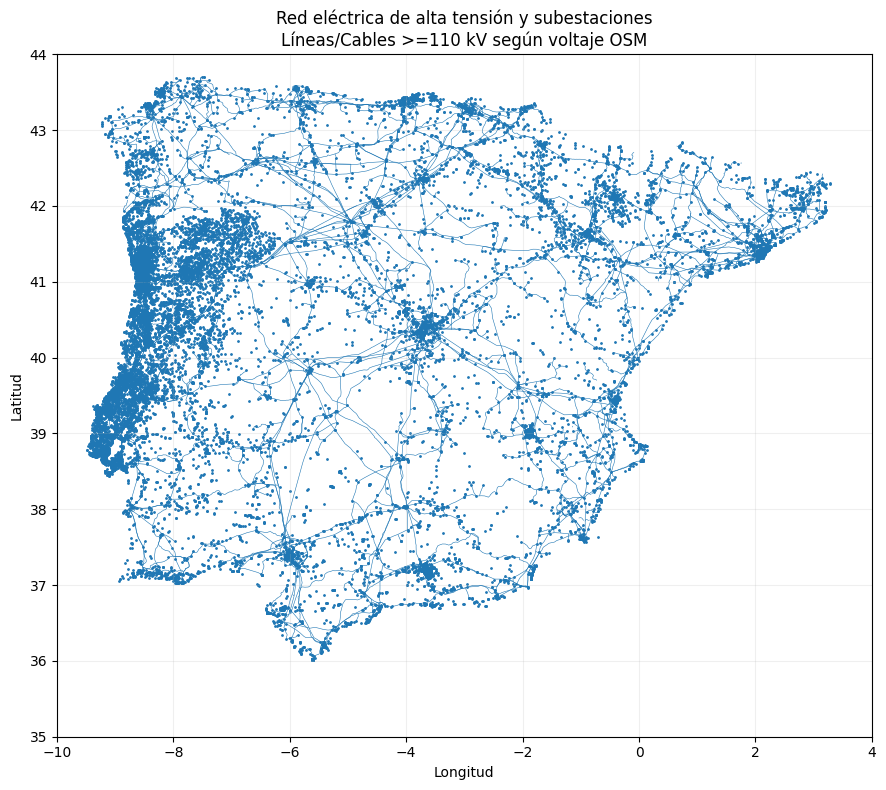

Mapa guardado en: /kaggle/working/06_infraestructura_electrica_osm_overpass_iberia/figures/mapa_infraestructura_electrica_iberia.png


In [22]:
# mapa de infraestructura eléctrica
fig, ax = plt.subplots(figsize=(10, 8))

lineas_alta_tension_gdf.plot(
    ax=ax,
    linewidth=0.4
)

subestaciones_gdf.plot(
    ax=ax,
    markersize=1
)

ax.set(
    title=(
        "Red eléctrica de alta tensión y subestaciones\n"
        "Líneas/Cables >=110 kV según voltaje OSM"
    ),
    xlabel="Longitud",
    ylabel="Latitud",
    xlim=(-10, 4),
    ylim=(35, 44)
)
ax.grid(alpha=0.2)

ruta_mapa_electrico = (
    FIGURES_DIR / "mapa_infraestructura_electrica_iberia.png"
)

plt.tight_layout()
plt.savefig(
    ruta_mapa_electrico,
    dpi=180,
    bbox_inches="tight"
)
plt.show()

print("Mapa guardado en:", ruta_mapa_electrico)

# Validación específica de Andorra

Comprobamos la cobertura eléctrica de Andorra mediante su límite territorial, sin realizar nuevas consultas a Overpass.

Los datos muestran 36 líneas o cables, 12 elementos de alta tensión y 8 subestaciones. Esta información confirma la presencia de infraestructura cartografiada, pero no permite conocer la capacidad disponible ni la viabilidad real de conexión.

In [23]:
# validacion de Andorra
andorra_3035 = (
    limites_tfb[
        limites_tfb["ADM0_A3"] == "AND"
    ]
    .to_crs(CRS_METRICO)
    .geometry
    .union_all()
)
lineas_andorra_3035 = gpd.clip(
    lineas_cables_3035,
    andorra_3035
)
alta_tension_andorra_3035 = gpd.clip(
    lineas_alta_tension_3035,
    andorra_3035
)
subestaciones_andorra_3035 = gpd.clip(
    subestaciones_3035,
    andorra_3035
)
resumen_andorra = pd.DataFrame({
    "capa": [
        "Líneas y cables",
        "Alta tensión",
        "Subestaciones"
    ],
    "registros": [
        len(lineas_andorra_3035),
        len(alta_tension_andorra_3035),
        len(subestaciones_andorra_3035)
    ]
})
resumen_andorra.to_csv(
    TABLAS_DIR / "tabla_infraestructura_electrica_andorra.csv",
    index=False
)
print(
    "Cobertura Andorra:",
    "disponible"
    if resumen_andorra["registros"].sum() > 0
    else "sin datos"
)
display(resumen_andorra)

Cobertura Andorra: disponible


,capa,registros
0,Líneas y cables,36
1,Alta tensión,12
2,Subestaciones,8


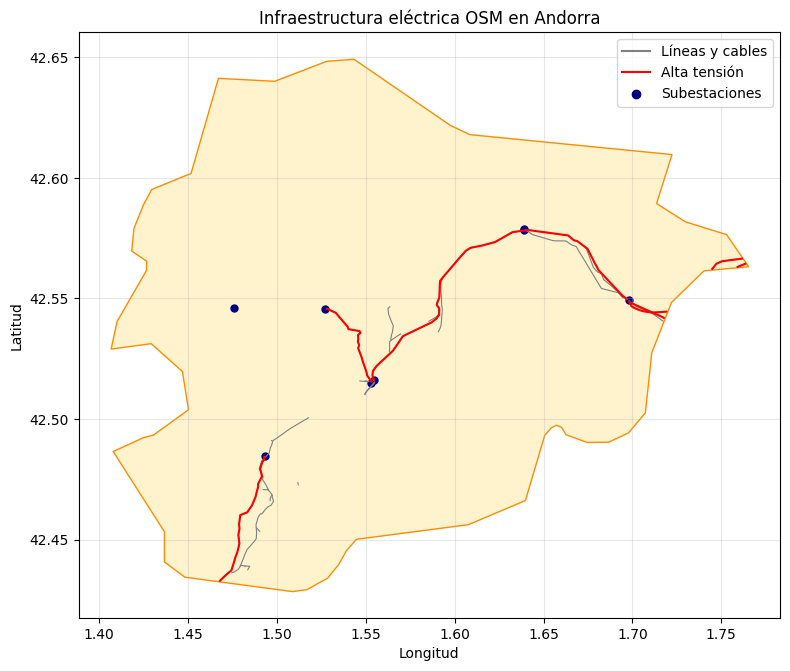

Mapa guardado en: /kaggle/working/06_infraestructura_electrica_osm_overpass_iberia/figures/mapa_infraestructura_electrica_andorra.png


In [24]:
# mapa de infraestructura eléctrica de Andorra
limite_andorra = limites_tfb[
    limites_tfb["ADM0_A3"] == "AND"
]

# capas a coordenadas geográficas
lineas_andorra = lineas_andorra_3035.to_crs(CRS_GEOGRAFICO)
alta_tension_andorra = alta_tension_andorra_3035.to_crs(CRS_GEOGRAFICO)
subestaciones_andorra = subestaciones_andorra_3035.to_crs(CRS_GEOGRAFICO)

fig, ax = plt.subplots(figsize=(8, 7))

limite_andorra.plot(
    ax=ax,
    color="#fff3cd",
    edgecolor="darkorange"
)
lineas_andorra.plot(
    ax=ax,
    color="gray",
    linewidth=0.8
)
alta_tension_andorra.plot(
    ax=ax,
    color="red",
    linewidth=1.5
)
subestaciones_andorra.plot(
    ax=ax,
    color="navy",
    markersize=25
)

ax.plot([], [], color="gray", label="Líneas y cables")
ax.plot([], [], color="red", label="Alta tensión")
ax.scatter([], [], color="navy", label="Subestaciones")

ax.set_title("Infraestructura eléctrica OSM en Andorra")
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
ax.legend()
ax.grid(alpha=0.3)

ruta_mapa_andorra = FIGURES_DIR / "mapa_infraestructura_electrica_andorra.png"

plt.tight_layout()
plt.savefig(ruta_mapa_andorra, dpi=180, bbox_inches="tight")
plt.show()

print("Mapa guardado en:", ruta_mapa_andorra)

In [25]:
# geopackage final
ruta_gpkg_final = (
    GPKG_DIR
    / "infraestructura_electrica_iberia_osm_final_epsg3035.gpkg"
)
ruta_gpkg_final.unlink(missing_ok=True)
capas_finales = [
    ("lineas_cables_3035", lineas_cables_3035),
    (
        "lineas_cables_alta_tension_110kv_3035",
        lineas_alta_tension_3035
    ),
    (
        "subestaciones_representativas_3035",
        subestaciones_3035
    )
]
for numero, (nombre, capa) in enumerate(capas_finales):
    capa.to_file(
        ruta_gpkg_final,
        layer=nombre,
        driver="GPKG",
        mode="w" if numero == 0 else "a"
    )
print("GeoPackage final:", ruta_gpkg_final)
print("Capas guardadas:", len(capas_finales))

GeoPackage final: /kaggle/working/06_infraestructura_electrica_osm_overpass_iberia/processed/geopackage/infraestructura_electrica_iberia_osm_final_epsg3035.gpkg
Capas guardadas: 3


In [26]:
# resumen final
resumen_final = pd.DataFrame([{
    "origen": "Kaggle Input" if USAR_INPUT else "Overpass",
    "lineas_cables": len(lineas_cables_3035),
    "alta_tension": len(lineas_alta_tension_3035),
    "subestaciones": len(subestaciones_3035),
    "lineas_andorra": len(lineas_andorra_3035),
    "alta_tension_andorra": len(
        alta_tension_andorra_3035
    ),
    "subestaciones_andorra": len(
        subestaciones_andorra_3035
    ),
    "crs": CRS_METRICO,
    "estado": "completado",
    "fecha_ejecucion": FECHA_EJECUCION
}])
resumen_final.to_csv(
    TABLAS_DIR / "tabla_resumen_final_electrico.csv",
    index=False
)
display(resumen_final)

,origen,lineas_cables,alta_tension,subestaciones,lineas_andorra,alta_tension_andorra,subestaciones_andorra,crs,estado,fecha_ejecucion
0,Kaggle Input,124709,11450,23366,36,12,8,EPSG:3035,completado,2026-09-10 21:15:38


In [27]:
# dashboard
import base64

def imagen_base64(ruta):
    return base64.b64encode(ruta.read_bytes()).decode("utf-8")

r = resumen_final.iloc[0]

html = f"""
<html>
<head>
<meta charset="UTF-8">
<title>Infraestructura eléctrica</title>
</head>

<body style="font-family: Arial; margin: 30px;">

<h1>Infraestructura eléctrica de Iberia y Andorra</h1>

<ul>
    <li>Líneas y cables: {r["lineas_cables"]:,}</li>
    <li>Alta tensión: {r["alta_tension"]:,}</li>
    <li>Subestaciones: {r["subestaciones"]:,}</li>
    <li>Líneas en Andorra: {r["lineas_andorra"]}</li>
    <li>Alta tensión en Andorra: {r["alta_tension_andorra"]}</li>
    <li>Subestaciones en Andorra: {r["subestaciones_andorra"]}</li>
</ul>

<h2>Mapa general</h2>
<img src="data:image/png;base64,{imagen_base64(ruta_mapa_electrico)}"
     style="width:100%; max-width:900px;">

<h2>Detalle de Andorra</h2>
<img src="data:image/png;base64,{imagen_base64(ruta_mapa_andorra)}"
     style="width:100%; max-width:900px;">

<p>
Los datos OSM permiten analizar proximidad territorial,
pero no garantizan capacidad ni viabilidad de conexión.
</p>

</body>
</html>
"""

ruta_dashboard = DASHBOARD_DIR / "dashboard_infraestructura_electrica.html"
ruta_dashboard.write_text(html, encoding="utf-8")

print("Dashboard guardado en:", ruta_dashboard)

Dashboard guardado en: /kaggle/working/06_infraestructura_electrica_osm_overpass_iberia/dashboard/dashboard_infraestructura_electrica.html


In [28]:
# Zip final
import zipfile

ruta_zip_final = (
    BASE_DIR
    / "06_infraestructura_electrica_iberia_andorra_final.zip"
)

archivos = [
    ruta_gpkg_final,
    ruta_mapa_electrico,
    ruta_mapa_andorra,
    ruta_dashboard,
    ruta_limites,
    *TABLAS_DIR.glob("*.csv")
]

ruta_zip_final.unlink(missing_ok=True)

with zipfile.ZipFile(
    ruta_zip_final,
    "w",
    zipfile.ZIP_DEFLATED
) as zipf:
    for archivo in archivos:
        if archivo.exists():
            zipf.write(
                archivo,
                archivo.relative_to(OUT_DIR)
            )

print("ZIP final:", ruta_zip_final)
print("Archivos:", len(archivos))
print(
    "Tamaño MB:",
    round(ruta_zip_final.stat().st_size / 1024**2, 2)
)

ZIP final: /kaggle/working/06_infraestructura_electrica_iberia_andorra_final.zip
Archivos: 14
Tamaño MB: 28.7


# Interpretación metodológica

Este notebook prepara la infraestructura eléctrica para España peninsular, Portugal continental y Andorra.

Usamos datos de OpenStreetMap procesados y disponibles en Kaggle Input. Mantenemos Overpass API como alternativa reproducible. Los límites de Natural Earth permiten definir el ámbito territorial y validar de forma específica la cobertura de Andorra.

Los resultados finales son:

- 124.709 líneas y cables;
- 11.450 elementos de alta tensión;
- 23.366 subestaciones;
- Andorra: 36 líneas, 12 elementos de alta tensión y 8 subestaciones.

Consideramos alta tensión los elementos con valores iguales o superiores a 110 kV cuando el atributo `voltage` está disponible.

Estas capas se usan para calcular longitudes de red, número de subestaciones y densidades territoriales. OSM representa la infraestructura cartografiada, pero no informa sobre capacidad disponible, congestión, costes ni viabilidad real de conexión.

El archivo principal para los notebooks posteriores es:

`processed/geopackage/infraestructura_electrica_iberia_osm_final_epsg3035.gpkg`